In [1]:
%pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 76.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

In [3]:
# Focando nos dados de estações do Brasil
df_stations = pd.read_csv('charging_stations_2025_world.csv')
df_br = df_stations[df_stations['country_code'] == 'BR'].copy()

/tmp/ipython-input-4213354319.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stations = pd.read_csv('charging_stations_2025_world.csv')


In [4]:
# Removendo dados faltantes de localização, se houver
df_br.dropna(subset=['latitude', 'longitude', 'power_kw'], inplace=True)

In [5]:
# Selecionando as features(características) para o modelo, usaremos latitude, longitude e a potência como um indicador de importância
features = df_br[['latitude', 'longitude', 'power_kw']]

In [6]:
# Normalizando os dados, é muinto importante que a potência não domine a distância geográfica
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [7]:
# Testando de 1 a 15 clusters para ver qual o número ideal
inertia = []
K = range(1, 15)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

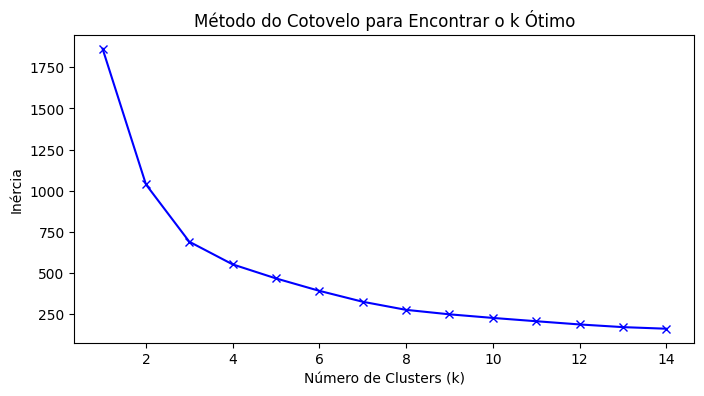

In [8]:
# Plotando o gráfico para visualização
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Encontrar o k Ótimo')
plt.show()

In [9]:
# Pelo gráfico, vamos escolher um número "k" onde a curva começa a suavizar

In [10]:
k_otimo = 10  # Colocando o valor mais interessande, se baseando no gráfico
kmeans = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
kmeans.fit(features_scaled)

KMeans(n_clusters=10, n_init=10, random_state=42)

In [11]:
# Adicionando os resultados (o cluster de cada posto) de volta ao nosso DataFrame
df_br['cluster'] = kmeans.labels_

In [12]:
# O modelo nos dá as coordenadas dos centros de cada cluster
# Precisamos reverter a normalização para interpretar as coordenadas e potência
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
df_centros = pd.DataFrame(cluster_centers, columns=['latitude_centro', 'longitude_centro', 'potencia_media_kw'])

In [13]:
print('='*15,'Centros Estratégicos para Novos Postos de Recarga', '='*15)
print('\nCada linha representa o "centro de gravidade" de uma região com alta densidade de postos.\n')
print(df_centros.to_markdown(index=False))

=============== Centros Estratégicos para Novos Postos de Recarga ===============

Cada linha representa o "centro de gravidade" de uma região com alta densidade de postos.

|   latitude_centro |   longitude_centro |   potencia_media_kw |
|------------------:|-------------------:|--------------------:|
|          -6.66997 |           -37.9292 |             36.9826 |
|         -14.8661  |           -49.0954 |             25.1321 |
|         -23.3095  |           -47.6007 |            146.471  |
|         -23.2509  |           -47.1643 |             57.4054 |
|         -28.6726  |           -51.9243 |             45.9263 |
|         -23.678   |           -46.5287 |            330      |
|          -7.03523 |           -37.8363 |            130      |
|         -23.8443  |           -47.2729 |             15.9067 |
|         -20.9386  |           -42.3714 |             18.8033 |
|          -4.62165 |           -44.4651 |             36.5462 |


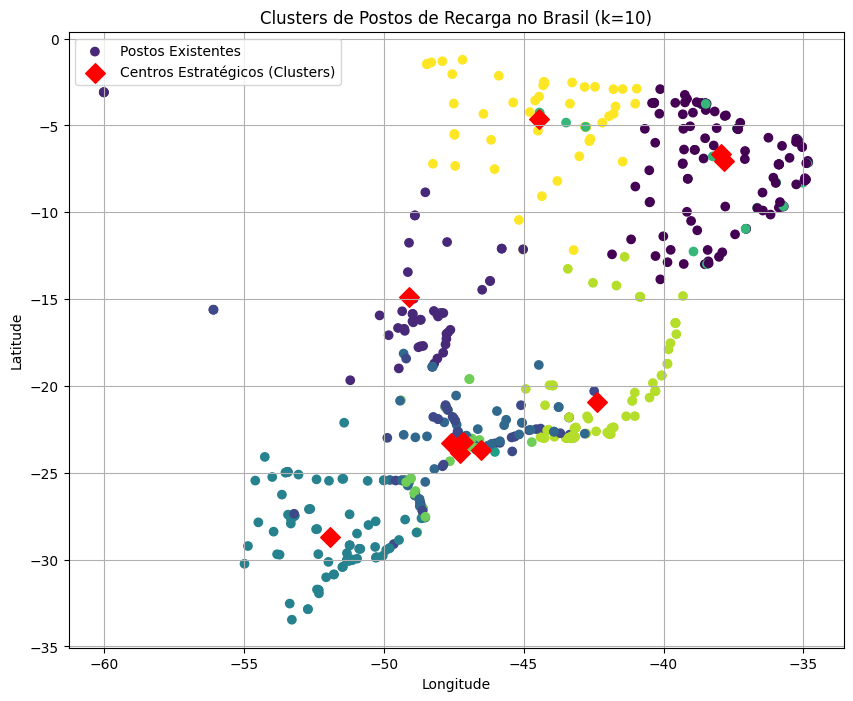

In [14]:
# Visualizando os clusters em um mapa
plt.figure(figsize=(10, 8))
plt.scatter(df_br['longitude'], df_br['latitude'], c=df_br['cluster'], cmap='viridis', marker='o', label='Postos Existentes')
plt.scatter(df_centros['longitude_centro'], df_centros['latitude_centro'], c='red', marker='D', s=100, label='Centros Estratégicos (Clusters)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Clusters de Postos de Recarga no Brasil (k={k_otimo})')
plt.legend()
plt.grid(True)
plt.show()

Criando outro mapa, o que foi feito acima não gostei muito.

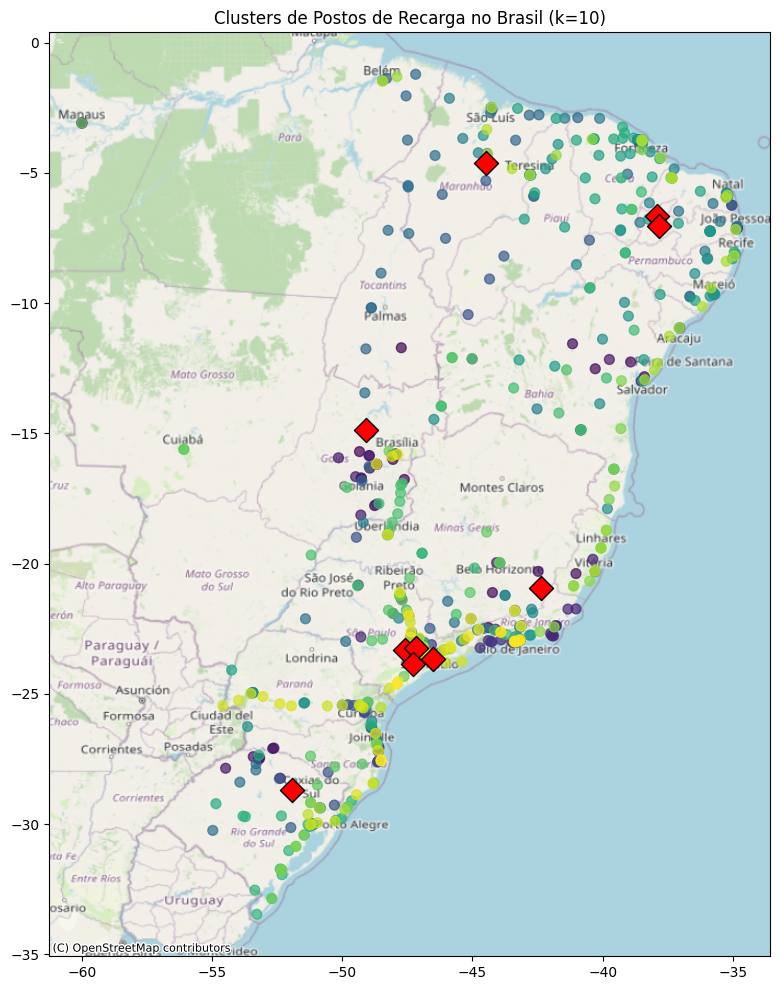

In [15]:
# Convertendo os dados para GeoDataFrame
gdf_br = gpd.GeoDataFrame(
    df_br,
    geometry=gpd.points_from_xy(df_br.longitude, df_br.latitude)
)
gdf_centros = gpd.GeoDataFrame(
    df_centros,
    geometry=gpd.points_from_xy(df_centros.longitude_centro, df_centros.latitude_centro)
)

# Criando a figura
fig, ax = plt.subplots(figsize=(12, 12))

# Plotando os pontos
gdf_br.plot(ax=ax, c=df_br['cluster'], cmap='viridis', markersize=50,
           alpha=0.7, legend=True)
gdf_centros.plot(ax=ax, color='red', marker='D', markersize=150,
                edgecolor='black')

# Adicionando o mapa de fundo
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title(f'Clusters de Postos de Recarga no Brasil (k={k_otimo})')
plt.show()